# Image Stitching / Panorama

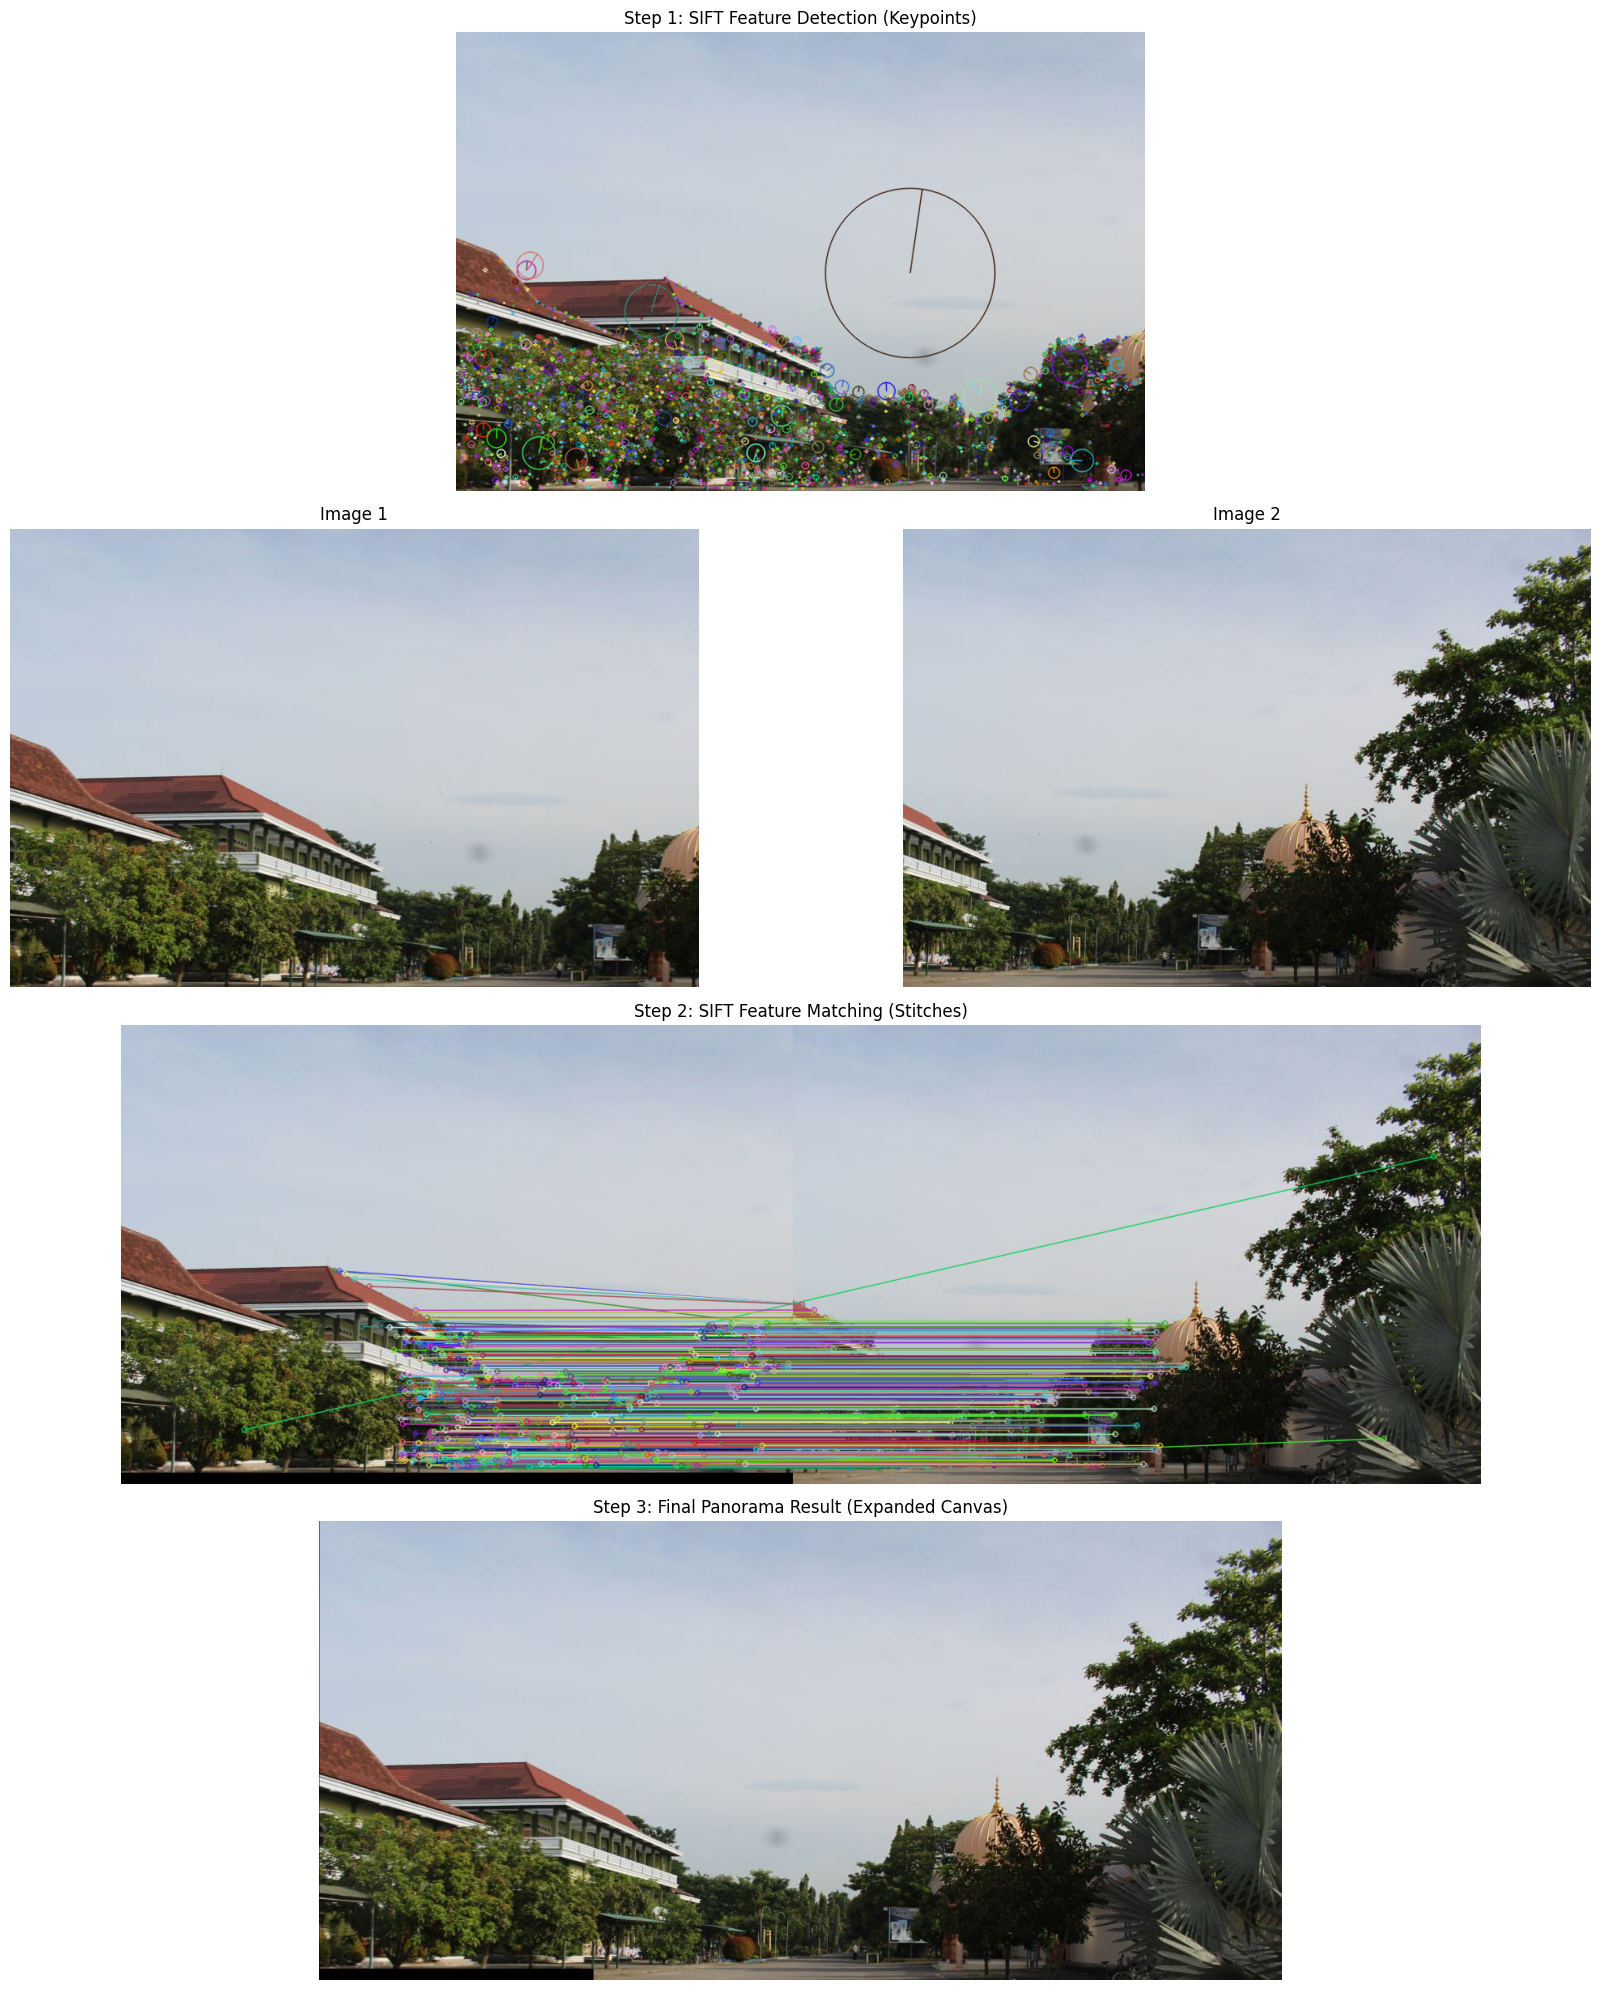

<Figure size 640x480 with 0 Axes>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Gambar (Pastikan path sesuai di Kaggle kamu)
path1 = '/kaggle/input/jalan-mendiro/images/jalan 1.jpg'
path2 = '/kaggle/input/jalan-mendiro/images/jalan 2.jpg'

img1 = cv2.imread(path1)
img2 = cv2.imread(path2)

# 2. SIFT Detection & Description 
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# --- TAMBAHAN VISUALISASI KEYPOINTS (Wajib untuk Bab 5.4) [cite: 25, 36] ---
# Kita gambar lingkaran fitur pada Image 1 sebagai sampel
img_kp_v = cv2.drawKeypoints(img1, kp1, None, 
                             flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Feature Matching menggunakan Brute-Force
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

# Lowe's Ratio Test untuk filter kecocokan fitur [cite: 39]
good_matches = []
for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good_matches.append(m)

# 3. Hitung Matriks Homografi & Kanvas Otomatis 
pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

H, _ = cv2.findHomography(pts1, pts2, cv2.RANSAC, 5.0)

h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]

# Menghitung batas kanvas agar tidak terpotong (Expanded Canvas)
corners_img1 = np.float32([[0, 0], [w1, 0], [w1, h1], [0, h1]]).reshape(-1, 1, 2)
warped_corners = cv2.perspectiveTransform(corners_img1, H)
corners_img2 = np.float32([[0, 0], [w2, 0], [w2, h2], [0, h2]]).reshape(-1, 1, 2)

all_corners = np.concatenate((warped_corners, corners_img2), axis=0)
[x_min, y_min] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
[x_max, y_max] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

# Matriks Translasi untuk kompensasi koordinat negatif
translation_dist = [-x_min, -y_min]
H_translation = np.array([[1, 0, translation_dist[0]], [0, 1, translation_dist[1]], [0, 0, 1]])

# 4. Warping dan Penggabungan Panorama [cite: 11, 34]
result_canvas = cv2.warpPerspective(img1, H_translation.dot(H), (x_max - x_min, y_max - y_min))
result_canvas[translation_dist[1]:h2 + translation_dist[1], translation_dist[0]:w2 + translation_dist[0]] = img2

# --- VISUALISASI LENGKAP UNTUK LAPORAN --- [cite: 25, 36]
plt.figure(figsize=(18, 20))

# Row 1: Visualisasi Keypoints (Deteksi Fitur)
plt.subplot(4, 1, 1)
plt.imshow(cv2.cvtColor(img_kp_v, cv2.COLOR_BGR2RGB))
plt.title("Step 1: SIFT Feature Detection (Keypoints)")
plt.axis('off')

# Row 2: Before Image 1 & 2
plt.subplot(4, 2, 3)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Image 1")
plt.axis('off')

plt.subplot(4, 2, 4)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title("Image 2")
plt.axis('off')

# Row 3: Feature Matching (Garis Penghubung)
img_matches = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None, 
                              flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.subplot(4, 1, 3)
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title("Step 2: SIFT Feature Matching (Stitches)")
plt.axis('off')

# Row 4: Hasil Akhir Panorama
plt.subplot(4, 1, 4)
plt.imshow(cv2.cvtColor(result_canvas, cv2.COLOR_BGR2RGB))
plt.title("Step 3: Final Panorama Result (Expanded Canvas)")
plt.axis('off')

plt.tight_layout()
plt.show()

# Simpan hasil final untuk dimasukkan ke laporan PDF [cite: 23]
plt.savefig('visualisasi_lengkap_uas_fiona.png', bbox_inches='tight')